In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet('fipe_silver.parquet')
df.head()

,nome_marca,nome_modelo,tipo_veiculo,nome_combustivel,ano_referencia,ano_modelo,valor_reais,idade_veiculo,segmentacao_veiculo
0,ADLY,Atv 100,moto,Gasolina,2026,2000.0,3231.0,26.0,Entrada
1,ADLY,Atv 100,moto,Gasolina,2026,2000.0,3181.0,26.0,Entrada
2,ADLY,Atv 100,moto,Gasolina,2026,2000.0,3189.0,26.0,Entrada
3,ADLY,Atv 100,moto,Gasolina,2026,2000.0,3197.0,26.0,Entrada
4,ADLY,Atv 100,moto,Gasolina,2025,2000.0,3204.0,25.0,Entrada


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5018080 entries, 0 to 5018079
Data columns (total 9 columns):
 #   Column               Dtype   
---  ------               -----   
 0   nome_marca           category
 1   nome_modelo          category
 2   tipo_veiculo         category
 3   nome_combustivel     category
 4   ano_referencia       int16   
 5   ano_modelo           float64 
 6   valor_reais          float64 
 7   idade_veiculo        float64 
 8   segmentacao_veiculo  object  
dtypes: category(4), float64(3), int16(1), object(1)
memory usage: 191.8+ MB


In [4]:
df.isna().sum()

nome_marca             0
nome_modelo            0
tipo_veiculo           0
nome_combustivel       0
ano_referencia         0
ano_modelo             0
valor_reais            0
idade_veiculo          0
segmentacao_veiculo    0
dtype: int64

In [5]:
df.describe()

,ano_referencia,ano_modelo,valor_reais,idade_veiculo
count,5.018080e+06,5.018080e+06,5.018080e+06,5.018080e+06
mean,2.021011e+03,2.006875e+03,1.019499e+05,1.413578e+01
std,2.969647e+00,9.714319e+00,2.439867e+05,9.683218e+00
min,2.016000e+03,1.981000e+03,3.380000e+02,-1.000000e+00
25%,2.019000e+03,1.999000e+03,1.816400e+04,6.000000e+00
50%,2.021000e+03,2.008000e+03,4.133600e+04,1.300000e+01
75%,2.024000e+03,2.015000e+03,9.921500e+04,2.100000e+01
max,2.026000e+03,2.027000e+03,9.603000e+06,4.500000e+01


In [6]:
df.isna().sum()

nome_marca             0
nome_modelo            0
tipo_veiculo           0
nome_combustivel       0
ano_referencia         0
ano_modelo             0
valor_reais            0
idade_veiculo          0
segmentacao_veiculo    0
dtype: int64

In [7]:
len(df['nome_marca'].unique())

216

In [8]:
df['nome_marca'].value_counts()

nome_marca
MERCEDES-BENZ    468515
VOLKSWAGEN       447817
FORD             383912
CHEVROLET        299316
FIAT             271586
                  ...  
SBM                  17
LEVA                 16
LEAPMOTOR            15
JETOUR               12
DENZA                 2
Name: count, Length: 216, dtype: int64

In [9]:
distribuicao_marcas = (df['nome_marca'].value_counts(normalize = True) * 100).round(2).reset_index()
distribuicao_marcas.columns = ['Marca', 'Porcentagem (%)']

qtd_modelos = df.groupby('nome_marca')['nome_modelo'].nunique().reset_index()
qtd_modelos.columns = ['Marca','Qtd Modelos']

distribuicao_marcas = pd.merge(distribuicao_marcas,qtd_modelos, on = 'Marca')
distribuicao_marcas.head(10)

C:\Users\nicol\AppData\Local\Temp\ipykernel_3972\1250562293.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qtd_modelos = df.groupby('nome_marca')['nome_modelo'].nunique().reset_index()


,Marca,Porcentagem (%),Qtd Modelos
0,MERCEDES-BENZ,9.34,853
1,VOLKSWAGEN,8.92,747
2,FORD,7.65,651
3,CHEVROLET,5.96,568
4,FIAT,5.41,587
5,VOLVO,4.17,434
6,SCANIA,3.65,433
7,BMW,3.54,455
8,HONDA,3.39,304
9,RENAULT,2.90,337


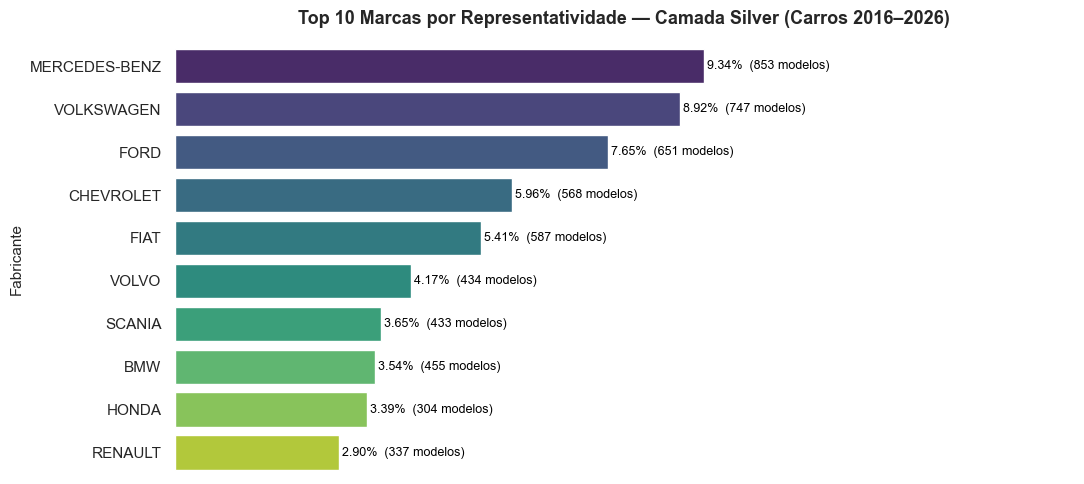

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = distribuicao_marcas.head(10).copy()
top10['Marca'] = top10['Marca'].astype(str)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=top10,
    x='Porcentagem (%)',
    y='Marca',
    hue='Marca',          
    palette='viridis',
    legend=False,
    ax=ax
)

for i, row in top10.iterrows():
    ax.text(
        row['Porcentagem (%)'] + 0.05,
        i,
        f"{row['Porcentagem (%)']:.2f}%  ({int(row['Qtd Modelos'])} modelos)",
        va='center',
        fontsize=9,
        color='black'
    )

ax.set_title('Top 10 Marcas por Representatividade — Camada Silver (Carros 2016–2026)',
             fontsize=13, pad=15, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Fabricante', fontsize=11)
ax.set_xlim(0, top10['Porcentagem (%)'].max() * 1.7)
ax.xaxis.set_visible(False)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [11]:
distribuicao_tipo_veiculo = (df['tipo_veiculo'].value_counts(normalize = True) * 100).round(2).reset_index()

distribuicao_tipo_veiculo.columns = ['Tipo', 'Porcentagem (%)']
distribuicao_tipo_veiculo

,Tipo,Porcentagem (%)
0,carro,61.24
1,caminhão,22.50
2,moto,16.26


In [12]:
segmentacao_tipo_veiculo = (df['segmentacao_veiculo'].value_counts(normalize = True) * 100).round(2).reset_index()

segmentacao_tipo_veiculo.columns = ['Segmentação', 'Porcentagem (%)']
segmentacao_tipo_veiculo

,Segmentação,Porcentagem (%)
0,Entrada,56.21
1,Intermediário,27.18
2,Premium,11.17
3,Luxo,5.44


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5018080 entries, 0 to 5018079
Data columns (total 9 columns):
 #   Column               Dtype   
---  ------               -----   
 0   nome_marca           category
 1   nome_modelo          category
 2   tipo_veiculo         category
 3   nome_combustivel     category
 4   ano_referencia       int16   
 5   ano_modelo           float64 
 6   valor_reais          float64 
 7   idade_veiculo        float64 
 8   segmentacao_veiculo  object  
dtypes: category(4), float64(3), int16(1), object(1)
memory usage: 191.8+ MB


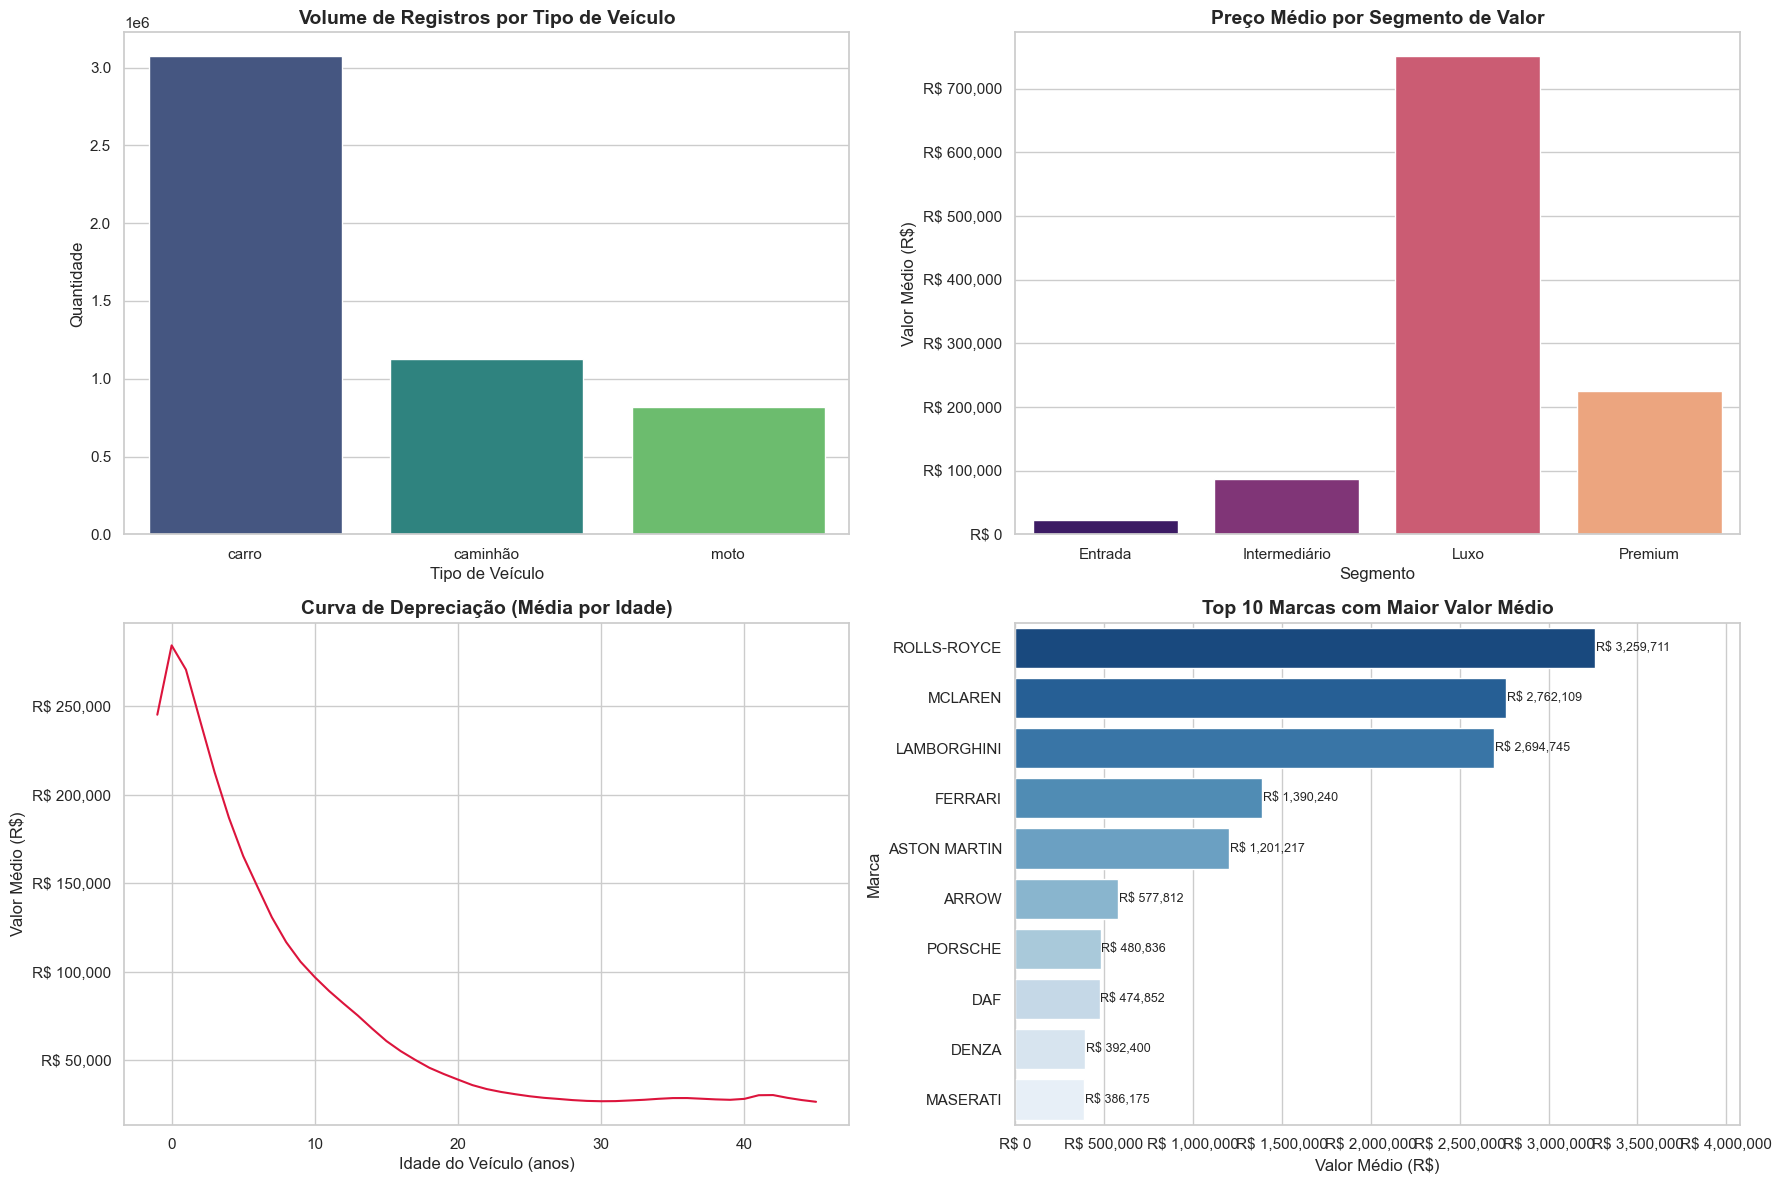

In [16]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- GRÁFICO 1: Volume por Tipo ---
df_tipo = df['tipo_veiculo'].value_counts().reset_index()
df_tipo['tipo_veiculo'] = df_tipo['tipo_veiculo'].astype(str)
sns.barplot(data=df_tipo, x='tipo_veiculo', y='count', hue='tipo_veiculo',
            palette='viridis', legend=False, ax=axes[0,0])
axes[0,0].set_title('Volume de Registros por Tipo de Veículo', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Tipo de Veículo')
axes[0,0].set_ylabel('Quantidade')

# --- GRÁFICO 2: Preço Médio por Segmento ---
df_seg = df.groupby('segmentacao_veiculo', observed=True)['valor_reais'].mean().reset_index()
df_seg['segmentacao_veiculo'] = df_seg['segmentacao_veiculo'].astype(str)
sns.barplot(data=df_seg, x='segmentacao_veiculo', y='valor_reais', hue='segmentacao_veiculo',
            palette='magma', legend=False, ax=axes[0,1])
axes[0,1].set_title('Preço Médio por Segmento de Valor', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Segmento')
axes[0,1].set_ylabel('Valor Médio (R$)')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

# --- GRÁFICO 3: Curva de Depreciação ---
df_dep = df.groupby('idade_veiculo', observed=True)['valor_reais'].mean().reset_index()
sns.lineplot(data=df_dep, x='idade_veiculo', y='valor_reais', ax=axes[1,0], color='crimson')
axes[1,0].set_title('Curva de Depreciação (Média por Idade)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Idade do Veículo (anos)')
axes[1,0].set_ylabel('Valor Médio (R$)')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

# --- GRÁFICO 4: Top 10 Marcas ---
df_marcas = (df.groupby('nome_marca', observed=True)['valor_reais']
               .mean()
               .sort_values(ascending=False)
               .head(10)
               .reset_index())
df_marcas['nome_marca'] = df_marcas['nome_marca'].astype(str)  # <- correção principal
sns.barplot(data=df_marcas, y='nome_marca', x='valor_reais', hue='nome_marca',
            palette='Blues_r', legend=False, ax=axes[1,1])
axes[1,1].set_title('Top 10 Marcas com Maior Valor Médio', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Valor Médio (R$)')
axes[1,1].set_ylabel('Marca')
axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

# Rótulos no gráfico 4
for i, row in df_marcas.iterrows():
    axes[1,1].text(
        row['valor_reais'] + 5000, i,
        f"R$ {row['valor_reais']:,.0f}",
        va='center', fontsize=9
    )
axes[1,1].set_xlim(0, df_marcas['valor_reais'].max() * 1.25)

plt.tight_layout()
plt.show()